In [90]:
import logging, sys
import pandas as pd
import hiring_compass_au.data.storage.mail_store as mail_store
import hiring_compass_au.workspace as workspace

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,   # important dans notebooks (reconfigure)
)

pd.set_option("display.max.columns", None)
pd.options.display.float_format = '{:,.0f}'.format
ws = workspace.get_workspace()

# Emails

In [2]:
with mail_store.get_connection(ws.db_path) as conn:
    emails = pd.read_sql_query(
        "SELECT * FROM emails",
        conn,
    )
    
emails.head()

,message_id,thread_id,from_email,subject,internal_date_ms,received_at,indexed_at,fetched_at,parsed_at,status,error,html_raw,hit_extract_count,persist_count,intended_use,template,parser_name,parser_version,parsed_confidence
0,19c1b5c999b4eb3b,19c1b5c999b4eb3b,jobmail@s.seek.com.au,20 new jobs for machine learning engineer,1769985577000,2026-02-01T22:39:37+00:00,2026-02-02T19:23:48+00:00,2026-02-04T18:51:44+00:00,2026-02-11T19:16:04+00:00,parsed,None,"<!doctype html><html lang=""und"" dir=""auto"" xml...",23,0,prod,None,seek_mail_parser,v1,100
1,19c1b10c30e076a7,19c1b10c30e076a7,jobmail@s.seek.com.au,20 new jobs for data analyst,1769980608000,2026-02-01T21:16:48+00:00,2026-02-02T19:23:48+00:00,2026-02-04T18:51:44+00:00,2026-02-11T19:16:04+00:00,parsed,None,"<!doctype html><html lang=""und"" dir=""auto"" xml...",23,0,prod,None,seek_mail_parser,v1,100
2,19c1b0cf11f33578,19c1b0cf11f33578,jobmail@s.seek.com.au,20 new jobs for data engineer,1769980358000,2026-02-01T21:12:38+00:00,2026-02-02T19:23:48+00:00,2026-02-04T18:51:44+00:00,2026-02-11T19:16:04+00:00,parsed,None,"<!doctype html><html lang=""und"" dir=""auto"" xml...",23,0,prod,None,seek_mail_parser,v1,99
3,19c1afb48779de5c,19c1afb48779de5c,jobmail@s.seek.com.au,20 new jobs for data scientist,1769979200000,2026-02-01T20:53:20+00:00,2026-02-02T19:23:48+00:00,2026-02-04T18:51:44+00:00,2026-02-11T19:16:04+00:00,parsed,None,"<!doctype html><html lang=""und"" dir=""auto"" xml...",23,0,prod,None,seek_mail_parser,v1,100
4,19c1add3cf3e11ec,19c1add3cf3e11ec,jobmail@s.seek.com.au,5 new jobs for ml engineer,1769977231000,2026-02-01T20:20:31+00:00,2026-02-02T19:23:48+00:00,2026-02-04T18:51:44+00:00,2026-02-11T19:16:04+00:00,parsed,None,"<!doctype html><html lang=""und"" dir=""auto"" xml...",8,0,prod,None,seek_mail_parser,v1,100


In [3]:
emails.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   message_id         100 non-null    object
 1   thread_id          100 non-null    object
 2   from_email         100 non-null    object
 3   subject            100 non-null    object
 4   internal_date_ms   100 non-null    int64 
 5   received_at        100 non-null    object
 6   indexed_at         100 non-null    object
 7   fetched_at         100 non-null    object
 8   parsed_at          100 non-null    object
 9   status             100 non-null    object
 10  error              0 non-null      object
 11  html_raw           100 non-null    object
 12  hit_extract_count  100 non-null    int64 
 13  persist_count      100 non-null    int64 
 14  intended_use       100 non-null    object
 15  template           0 non-null      object
 16  parser_name        100 non-null    object
 17

In [15]:
for c in ["received_at","indexed_at","fetched_at","parsed_at"]:
    emails[c] = pd.to_datetime(emails[c])

In [16]:
emails.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   message_id         100 non-null    object             
 1   thread_id          100 non-null    object             
 2   from_email         100 non-null    object             
 3   subject            100 non-null    object             
 4   internal_date_ms   100 non-null    int64              
 5   received_at        100 non-null    datetime64[ns, UTC]
 6   indexed_at         100 non-null    datetime64[ns, UTC]
 7   fetched_at         100 non-null    datetime64[ns, UTC]
 8   parsed_at          100 non-null    datetime64[ns, UTC]
 9   status             100 non-null    object             
 10  error              0 non-null      object             
 11  html_raw           100 non-null    object             
 12  hit_extract_count  100 non-null    int64           

In [17]:
emails.describe()

,internal_date_ms,hit_extract_count,persist_count,parsed_confidence
count,1.000000e+02,100.000000,100.0,100.000000
mean,1.770026e+12,21.440000,0.0,99.930000
std,4.999818e+08,3.885534,0.0,0.355477
min,1.769207e+12,6.000000,0.0,97.000000
25%,1.769612e+12,23.000000,0.0,100.000000
50%,1.770025e+12,23.000000,0.0,100.000000
75%,1.770444e+12,23.000000,0.0,100.000000
max,1.770850e+12,23.000000,0.0,100.000000


# Job Hits

In [91]:
with mail_store.get_connection(ws.db_path) as conn:
    job_hits = pd.read_sql_query(
        "SELECT * FROM email_job_hits",
        conn,
    )

job_hits.head()

,hit_id,message_id,fingerprint,template,title,company,suburb,city,state,location_raw,salary_min,salary_max,salary_period,salary_raw,debug_lines,out_url,out_url_norm,hit_context,source,hit_confidence,parser_name,parser_version,promote_status,promote_reason,job_id,canonical_url,canonical_status,http_status,attempt_count,next_retry_at,last_attempt_at,canon_error
0,1,19becf1df76aaeee,38a623362bf920ad,None,Process Engineer - Laboratory,CSL Limited,None,Melbourne,VIC,Melbourne VIC,NaN,NaN,None,None,"[""Process Engineer - Laboratory CSL Limited Me...",https://email.s.seek.com.au/uni/ss/c/u001.Mgc0...,None,None,seek,87,seek_mail_parser,v1,pending,None,89853693,https://www.seek.com.au/job/89853693,ok,302,1,None,2026-02-11T19:16:05+00:00,None
1,2,19becf1df76aaeee,d40171251a4a0de6,None,"Principal AI / Data Engineer | Databricks, Spa...",DyFlex Solutions,None,Sydney,NSW,Sydney NSW,NaN,NaN,None,None,"[""Principal AI / Data Engineer | Databricks, S...",https://email.s.seek.com.au/uni/ss/c/u001.Mgc0...,None,None,seek,87,seek_mail_parser,v1,pending,None,89859151,https://www.seek.com.au/job/89859151,ok,302,1,None,2026-02-11T19:16:06+00:00,None
2,3,19becf1df76aaeee,893bb0208277480f,None,Project Engineer - Food Manufacturing Melbourne,Metromotion Pty Ltd,Mount Waverley,Melbourne,VIC,"Mount Waverley, Melbourne VIC",NaN,NaN,None,None,"[""Project Engineer - Food Manufacturing Melbou...",https://email.s.seek.com.au/uni/ss/c/u001.Mgc0...,None,None,seek,87,seek_mail_parser,v1,pending,None,89899915,https://www.seek.com.au/job/89899915,ok,302,1,None,2026-02-11T19:16:06+00:00,None
3,4,19becf1df76aaeee,eca840c6c31c4251,None,Senior Machine Learning Engineer,The Onset,None,Sydney,NSW,Sydney NSW,"165,000","165,000",year,"$165,000 + Super + Bonus","[""Senior Machine Learning Engineer The Onset S...",https://email.s.seek.com.au/uni/ss/c/u001.Mgc0...,None,None,seek,100,seek_mail_parser,v1,pending,None,89855926,https://www.seek.com.au/job/89855926,ok,302,1,None,2026-02-11T19:16:07+00:00,None
4,5,19becf1df76aaeee,cad0953785a9048f,None,Senior AI Engineer - ASX200 Enterprise,Galileo Search,None,Sydney,NSW,Sydney NSW,NaN,NaN,None,Awesome Salary and Benefits,"[""Senior AI Engineer - ASX200 Enterprise Galil...",https://email.s.seek.com.au/uni/ss/c/u001.Mgc0...,None,None,seek,97,seek_mail_parser,v1,pending,None,89866885,https://www.seek.com.au/job/89866885,ok,302,1,None,2026-02-11T19:16:07+00:00,None


In [92]:
job_hits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2144 entries, 0 to 2143
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hit_id            2144 non-null   int64  
 1   message_id        2144 non-null   object 
 2   fingerprint       2142 non-null   object 
 3   template          0 non-null      object 
 4   title             2144 non-null   object 
 5   company           2144 non-null   object 
 6   suburb            647 non-null    object 
 7   city              2142 non-null   object 
 8   state             2142 non-null   object 
 9   location_raw      2142 non-null   object 
 10  salary_min        696 non-null    float64
 11  salary_max        696 non-null    float64
 12  salary_period     699 non-null    object 
 13  salary_raw        831 non-null    object 
 14  debug_lines       2144 non-null   object 
 15  out_url           2144 non-null   object 
 16  out_url_norm      0 non-null      object 


In [24]:
job_hits.describe()

,hit_id,salary_min,salary_max,hit_confidence,http_status,attempt_count
count,"2,144",696,696,"2,144","2,144","2,144"
mean,"1,072","103,406","120,644",92,302,1
std,619,"51,872","57,934",6,0,0
min,1,39,39,48,302,1
25%,537,"83,701","110,000",87,302,1
50%,"1,072","120,000","137,475",87,302,1
75%,"1,608","140,000","160,000",100,302,1
max,"2,144","250,000","300,000",100,302,1


### Hit confidence

In [28]:
job_hits[job_hits["hit_confidence"]==48]

,hit_id,message_id,fingerprint,template,title,company,suburb,city,state,location_raw,salary_min,salary_max,salary_period,salary_raw,debug_lines,out_url,out_url_norm,hit_context,source,hit_confidence,parser_name,parser_version,promote_status,promote_reason,job_id,canonical_url,canonical_status,http_status,attempt_count,next_retry_at,last_attempt_at,canon_error
1009,1010,19c1b0cf11f33578,None,None,Amaze - Cloud Data Engineer,Hexaware,None,None,None,None,NaN,NaN,None,None,"[""Amaze - Cloud Data Engineer Hexaware Austral...",https://email.s.seek.com.au/uni/ss/c/u001.Mgc0...,None,None,seek,48,seek_mail_parser,v1,pending,None,90052738,https://www.seek.com.au/job/90052738,ok,302,1,None,2026-02-11T19:47:26+00:00,None
1065,1066,19c1b5c999b4eb3b,None,None,Amaze - Cloud Data Engineer,Hexaware,None,None,None,None,NaN,NaN,None,None,"[""Amaze - Cloud Data Engineer Hexaware Austral...",https://email.s.seek.com.au/uni/ss/c/u001.Mgc0...,None,None,seek,48,seek_mail_parser,v1,pending,None,90052738,https://www.seek.com.au/job/90052738,ok,302,1,None,2026-02-11T19:48:08+00:00,None


### Salary exploration

In [18]:
df_year = job_hits[job_hits["salary_period"] == "year"][["salary_min", "salary_max"]].copy()
df_month = job_hits[job_hits["salary_period"] == "month"][["salary_min", "salary_max"]].copy()
df_day = job_hits[job_hits["salary_period"] == "day"][["salary_min", "salary_max"]].copy()
df_hour = job_hits[job_hits["salary_period"] == "hour"][["salary_min", "salary_max"]].copy()


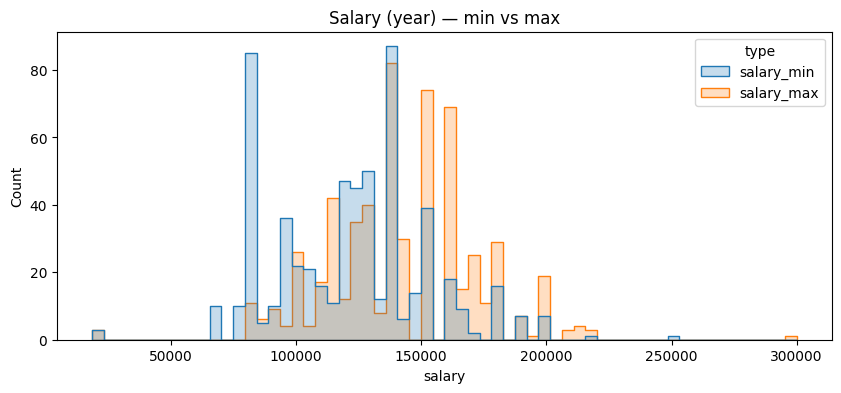

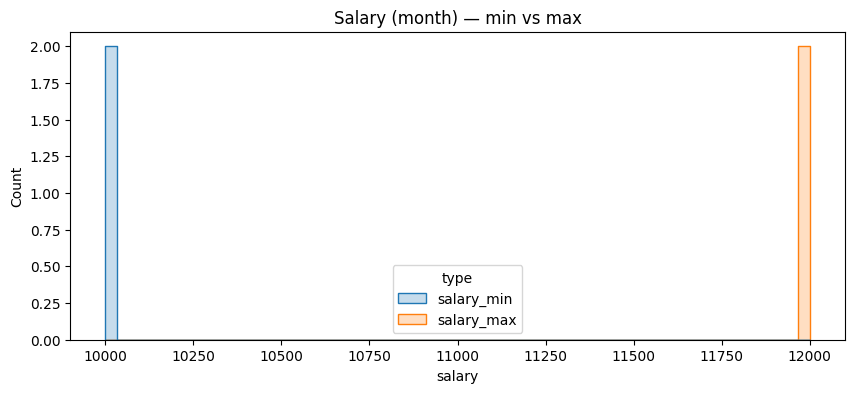

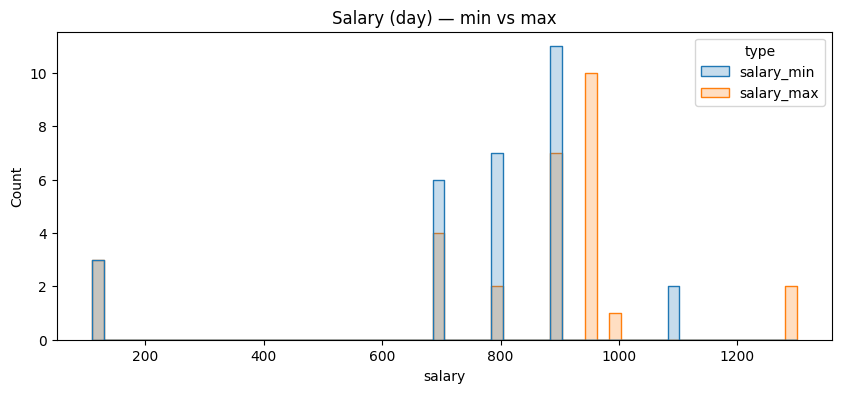

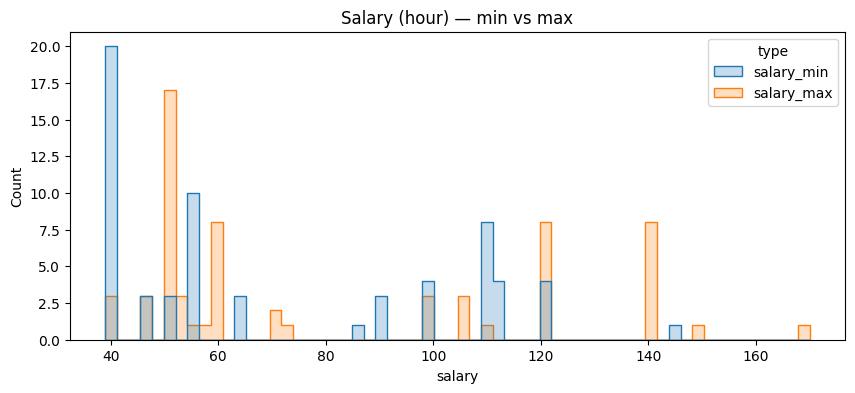

In [21]:
df_list = [(df_year,"year"), (df_month,"month"), (df_day,"day"), (df_hour,"hour")]

for df,time in df_list:
    long = df.melt(value_vars=["salary_min", "salary_max"], var_name="type", value_name="salary")
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(long, x="salary", hue="type", bins=60, element="step", stat="count", common_norm=False, ax=ax)
    ax.set_title(f"Salary ({time}) — min vs max")
    plt.show()

### Canonical fingerprint vs job_id

##### how many fingerprint by job_id (split)

In [93]:
job_hits[["job_id","fingerprint"]].groupby("job_id").nunique().value_counts()

fingerprint
1              568
0                1
2                1
Name: count, dtype: int64

In [94]:
job_to_fp_n = (
    job_hits.dropna(subset=["fingerprint", "job_id"])
            .groupby("job_id")["fingerprint"]
            .nunique()
)
bad_job_ids = job_to_fp_n[job_to_fp_n > 1].sort_values(ascending=False)
bad_job_ids_list = bad_job_ids.index.tolist()
cols = ["job_id","fingerprint","title","company","location_raw","salary_raw","canonical_url"]
for bad_job_id in bad_job_ids_list:
    display(job_hits[job_hits["job_id"]==bad_job_id][cols].sort_values(["fingerprint","job_id"]).drop_duplicates())

,job_id,fingerprint,title,company,location_raw,salary_raw,canonical_url
348,89918382,29e2a99d0d1b8a73,Business Intelligence Analyst,Anglicare SQ,"Fortitude Valley, Brisbane QLD",None,https://www.seek.com.au/job/89918382
495,89918382,7ee558db641a2319,BI Analyst,Anglicare SQ,"Fortitude Valley, Brisbane QLD",None,https://www.seek.com.au/job/89918382


the title changed

##### how many job_id by fingerprint (collisions)

In [95]:
job_hits[["job_id","fingerprint"]].groupby("fingerprint").nunique().value_counts()

job_id
1         558
2           6
Name: count, dtype: int64

In [96]:
fp_to_jobid_n = (
    job_hits.dropna(subset=["fingerprint", "job_id"])
            .groupby("fingerprint")["job_id"]
            .nunique()
)
bad_fps = fp_to_jobid_n[fp_to_jobid_n > 1].sort_values(ascending=False)
bad_fp_list = bad_fps.index.tolist()
cols = ["fingerprint","job_id","title","company","location_raw","salary_raw","canonical_url"]
for bad_fp in bad_fp_list:
    display(job_hits[job_hits["fingerprint"]==bad_fp][cols].sort_values(["fingerprint","job_id"]).drop_duplicates())

,fingerprint,job_id,title,company,location_raw,salary_raw,canonical_url
993,04b40ea8cb9bf860,90045747,"Senior Data Scientist, GTM Analytics",Airwallex,Sydney NSW,None,https://www.seek.com.au/job/90045747
1089,04b40ea8cb9bf860,90058591,"Senior Data Scientist, GTM Analytics",Airwallex,Sydney NSW,None,https://www.seek.com.au/job/90058591


,fingerprint,job_id,title,company,location_raw,salary_raw,canonical_url
784,1b08740efea9b052,89999243,Analytics Engineer,ABC,Melbourne VIC,None,https://www.seek.com.au/job/89999243
890,1b08740efea9b052,89999244,Analytics Engineer,ABC,Melbourne VIC,None,https://www.seek.com.au/job/89999244


,fingerprint,job_id,title,company,location_raw,salary_raw,canonical_url
102,52b9df4d9e58ab40,89900492,Machine Learning & AI Engineer | SQL,DyFlex Solutions,Sydney NSW,None,https://www.seek.com.au/job/89900492
432,52b9df4d9e58ab40,89950644,Machine Learning & AI Engineer | SQL,DyFlex Solutions,Sydney NSW,None,https://www.seek.com.au/job/89950644


,fingerprint,job_id,title,company,location_raw,salary_raw,canonical_url
24,58d0abf8cdaf45bc,89852313,Data Scientist,SEEK Limited,"Cremorne, Melbourne VIC",None,https://www.seek.com.au/job/89852313
1425,58d0abf8cdaf45bc,90143573,Data Scientist,SEEK Limited,"Cremorne, Melbourne VIC",None,https://www.seek.com.au/job/90143573


,fingerprint,job_id,title,company,location_raw,salary_raw,canonical_url
1253,b88b4af8a35679c3,90095565,Business Insights Analyst,AstraZeneca,Sydney NSW,None,https://www.seek.com.au/job/90095565
1902,b88b4af8a35679c3,90207353,Business Insights Analyst,AstraZeneca,Sydney NSW,None,https://www.seek.com.au/job/90207353


,fingerprint,job_id,title,company,location_raw,salary_raw,canonical_url
888,f305bc5b1f2de487,90045631,"Senior Data Scientist, GTM Analytics",Airwallex,Melbourne VIC,None,https://www.seek.com.au/job/90045631
1087,f305bc5b1f2de487,90058037,"Senior Data Scientist, GTM Analytics",Airwallex,Melbourne VIC,None,https://www.seek.com.au/job/90058037
